In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import pandas as pd
import networkx as nx
import scipy
import re
import pathpy as pp
from glob import glob
import h5py
#import nxviz
#from nxviz.plots_cust import CircosPlot, MatrixPlot, ArcPlot, BasePlot
sub_path  ='X:\\4 e-Lab\\' # y:\\eLab

# Importing libraries 
import statsmodels.api as sm 
from statsmodels.formula.api import ols 
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import pandas as pd

import sys

sys.path.append('T:\EL_experiment\Codes\CCEP_human\Python_Analysis/py_functions')
import basic_func as bf
import load_summary as ls
sys.path.append('T:\\EL_experiment\Codes\CCEP_human\Python_Analysis\py_functions')
sys.path.append('X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram')
sys.path.append('T:\\EL_experiment\Codes\\UBELIX_EvM\\NMF\\functions')
path_connectogram = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram'
from main_script import ConnectogramPlotter

cwd = os.getcwd()

##all
cond_vals = np.arange(4)
cond_labels = ['BM', 'BL', 'Fuma', 'Benzo']
cond_colors = ['#494159', '#594157', "#F1BF98", "#8FB996"]
dist_groups = np.array([[0, 15], [15, 30], [30, 5000]])
dist_labels = ['local (<15 mm)', 'short (<30mm)', 'long']
sub_path = 'X:\\4 e-Lab\\'  # y:\\eLab
group_labels = ['local direct', 'long direct', 'indirect']

##
# only sleep subjs
subjs = ["EL010", "EL011", "EL014", "EL015", "EL016", "EL017", "EL019", "EL020", "EL021",
         "EL022", "EL025", "EL026", "EL027","EL028"]
data_con_file = sub_path+'\EvM\Projects\EL_experiment\Analysis\Patients\Across\BrainMapping\Sleep\connectogram\\data_con_stat.csv'


In [2]:
folder = 'BrainMapping'
cond_folder = 'CR'  # Condition = 'Hour', 'Condition', 'Ph'
Fs = 500
dur = np.zeros((1, 2), dtype=np.int32)
t0 = 1
dur[0, 0] = -t0
dur[0, 1] = 3

#dur[0,:]       = np.int32(np.sum(abs(dur)))
x_ax = np.arange(dur[0, 0], dur[0, 1], (1 / Fs))
color_d, color_dist, color_group, color_elab = ls.get_color()

In [3]:
cwp = os.getcwd()

In [4]:
CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
tab_region = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='plot')
tab_region = tab_region.sort_values('Order').reset_index(drop=True)
regions_all = tab_region.Area.values
region_col = tab_region.color.values

CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
all_region = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='atlas')

In [5]:
import load_summary as ls
#import BM_across_plots as plotting

cwd = os.getcwd()

##all
cond_vals = np.arange(4)
cond_labels = ['BM', 'BL', 'Fuma', 'Benzo']
cond_colors = ['#494159', '#594157', "#F1BF98", "#8FB996"]
dist_groups = np.array([[0, 15], [15, 30], [30, 5000]])
dist_labels = ['local (<15 mm)', 'short (<30mm)', 'long']
sub_path = 'X:\\4 e-Lab\\'  # y:\\eLab


In [144]:
subjs = ["EL010", "EL011", "EL012", "EL013", "EL014", "EL015", "EL016", "EL019", "EL021",
         "EL022", "EL024", "EL026", "EL027", "EL020", "EL028"]

for subj in subjs:
    path = os.path.join('D:\\Patients', subj) 
    if not os.path.isdir(path): 
        os.mkdir(path)
    path = os.path.join('D:\\Patients', subj, 'Electrodes') 
    if not os.path.isdir(path): 
        os.mkdir(path)
    path = os.path.join('D:\\Patients', subj, 'Imaging') 
    if not os.path.isdir(path): 
        os.mkdir(path)
    path = os.path.join('D:\\Patients', subj, 'Imaging', 'FS') 
    if not os.path.isdir(path): 
        os.mkdir(path)
    path = os.path.join('D:\\Patients', subj, 'Imaging', 'leadDBS') 
    if not os.path.isdir(path): 
        os.mkdir(path)

In [ ]:
os.path

## DATA

In [6]:
subj = "EL011"
path_patient_analysis = os.path.join(sub_path, 'EvM', 'Projects', 'EL_experiment', 'Analysis', 'Patients', subj)

path_gen = os.path.join(sub_path+'\Patients\\' + subj)
if not os.path.exists(path_gen):
    path_gen = 'T:\\EL_experiment\\Patients\\' + subj
path_patient = path_gen + '\Data\EL_experiment'  # os.path.dirname(os.path.dirname(cwd))+'/Patients/'+subj
path_infos = os.path.join(path_gen, 'Electrodes')
# labels
files_list = glob(path_patient_analysis + '\\' + folder + '/data/Stim_list_*')
i = 0
stimlist_file = path_patient_analysis + '\\' + folder + '\\' + cond_folder + '\\data\\stimlist_' + cond_folder + '.csv'
stimlist = pd.read_csv(stimlist_file)
lbls = pd.read_excel(os.path.join(path_infos, subj + "_labels.xlsx"), header=0, sheet_name='BP')
if "type" in lbls.columns:
    lbls = lbls[lbls.type=='SEEG']
    lbls = lbls.reset_index(drop=True)
labels_all, labels_region, labels_clinic, coord_all, StimChans, StimChanSM, StimChansC, StimChanIx, stimlist = bf.get_Stim_chans(
    stimlist,
    lbls)
stimlist_sleep = pd.read_csv(os.path.join(path_patient_analysis, 'stimlist_hypnogram.csv'))
file_con = path_patient_analysis + '\\' + folder + '/' + cond_folder + '/data/con_trial_all.csv'
con_trial = pd.read_csv(file_con)
badchans = pd.read_csv(path_patient_analysis + '/BrainMapping/data/badchan.csv')
bad_chans = np.unique(np.array(np.where(badchans.values[:, 1:] == 1))[0, :])
con_trial = bf.add_sleepstate(con_trial)

In [7]:
h5_file = path_patient_analysis + '\\' + folder + '\\' + cond_folder + '\\data\\EEG_' + cond_folder + '.h5'
if os.path.isfile(h5_file):
    print('loading h5')
    EEG_resp = h5py.File(h5_file)
    EEG_resp = EEG_resp['EEG_resp']

loading h5


In [8]:
con_trial.loc[con_trial.Sig < 0, 'Sig'] = np.nan
con_trial['LL_sig'] = con_trial['LL']*con_trial['Sig']
df = con_trial[con_trial.Sig >=0].reset_index(drop=True)

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def compute_correlation_matrix(signal_data, Fs=500, start_time=-0.5, end_time=0, t0 = 1):
    """
    Compute the Pearson correlation for each pair of time series across all trials
    for a specific time window.

    Parameters:
    - signal_data: Input data as a 3D array (channels x trials x time_points).
    - Fs: Sampling frequency in Hz.
    - start_time: Start of the time window in seconds.
    - end_time: End of the time window in seconds.

    Returns:
    - 3D correlation matrix (channels x channels x trials).
    """
    # Determine the time window in samples
    start_sample = int((start_time + t0) * Fs)  # Adding 1s because the epoch starts at -1s
    end_sample = int((end_time + t0) * Fs)
    
    n_channels, n_trials, _ = signal_data.shape
    n_trials = 100
    correlation_matrix = np.zeros((n_channels, n_channels, n_trials))

    # Compute Pearson correlation for each pair of channels across all trials
    for trial in range(n_trials):
        for i in range(n_channels):
            for j in range(i, n_channels):  # Utilize symmetry, compute once
                corr, _ = pearsonr(signal_data[i, trial, start_sample:end_sample],
                                   signal_data[j, trial, start_sample:end_sample])
                correlation_matrix[i, j, trial] = corr
                if i != j:
                    correlation_matrix[j, i, trial] = corr  # Fill the symmetric value

    return correlation_matrix

def plot_vectorized_correlation_matrix(correlation_matrix, absolut = True):
    """
    Plot the vectorized correlation matrix as a heatmap.

    Parameters:
    - correlation_matrix: 3D array (channels x channels x trials).
    """
    if correlation_matrix.ndim ==3:
        correlation_matrix = correlation_matrix.reshape(-1, correlation_matrix.shape[2])
    fig = plt.figure(figsize=(5, 10))
    fig.patch.set_facecolor('xkcd:white')
    if absolut:
        plt.imshow(abs(correlation_matrix), interpolation = 'none', aspect='auto', origin='lower', cmap='binary', vmin = 0, vmax = 1)
    else:
        plt.imshow(correlation_matrix, interpolation = 'none', aspect='auto', origin='lower', cmap='seismic', vmin = -1, vmax = 1)
    plt.colorbar(label='Pearson Correlation')
    plt.xlabel('Trials')
    plt.ylabel('Connection')
    plt.title('Vectorized Correlation Matrix Across Trials')
    plt.show()

# Example usage (signal_data should be loaded with your data)
# signal_data = ...  # Load your data here
# correlation_matrix = compute_correlation_matrix(signal_data)
# plot_vectorized_correlation_matrix(correlation_matrix)


In [10]:
def compute_correlation_matrix_efficient(signal_data, start_time=-0.2, end_time=-0.05,  Fs=500, t0 = 1):
    """
    Efficiently compute the Pearson correlation for each pair of time series
    across all trials for a specific time window, using vectorized operations.

    Parameters:
    - signal_data: Input data as a 3D array (channels x trials x time_points).
    - Fs: Sampling frequency in Hz.
    - start_time: Start of the time window in seconds.
    - end_time: End of the time window in seconds.

    Returns:
    - 3D correlation matrix (channels x channels x trials).
    """
    start_sample = int((start_time + t0) * Fs)
    end_sample = int((end_time + t0) * Fs)
    signal_window = signal_data[:, :, start_sample:end_sample]

    # Normalize the signal in the window
    mean = signal_window.mean(axis=2, keepdims=True)
    std = signal_window.std(axis=2, keepdims=True)
    normalized_signal = (signal_window - mean) / std

    n_channels, n_trials, _ = signal_window.shape
    correlation_matrix = np.empty((n_channels, n_channels, n_trials))

    # Compute correlations
    for i in range(n_channels):
        for j in range(i, n_channels):
            product = np.mean(normalized_signal[i] * normalized_signal[j], axis=1)
            correlation_matrix[i, j, :] = product
            correlation_matrix[j, i, :] = product  # Exploit symmetry

    return correlation_matrix

In [11]:
def compute_correlation_2d(signal_data, con_trial, start_time=-0.2, end_time=-0.05,  Fs=500, t0 = 1):
    """
    Efficiently compute the Pearson correlation for each pair of time series
    across all trials for a specific time window, using vectorized operations.

    Parameters:
    - signal_data: Input data as a 3D array (channels x trials x time_points).
    - con_trial: pandas dataframe with information about Stim, Chan connection
    - Fs: Sampling frequency in Hz.
    - start_time: Start of the time window in seconds.
    - end_time: End of the time window in seconds.

    Returns:
    - 2D correlation matrix (channels x channels x trials).
    """
    start_sample = int((start_time + t0) * Fs)
    end_sample = int((end_time + t0) * Fs)
    con_trial['Con_ID'] = con_trial.groupby(['Stim', 'Chan']).ngroup()
    n_channels, n_trials, _ = signal_data.shape
    # correlation_matrix = np.empty((n_channels, n_channels, n_trials))
    correlation_matrix =  np.empty((len(np.unique(con_trial.Con_ID)), n_trials))
    # Compute correlations for each connection and trial

    for sc in range(n_channels):
        for rc in range(sc, n_channels):  # Utilize symmetry, compute once
            if (len(con_trial.loc[(con_trial.Chan==rc)&(con_trial.Stim==sc)])>0):
                con_id = con_trial.loc[(con_trial.Chan==rc)&(con_trial.Stim==sc), 'Con_ID'].values[0]
                con_id_back = -1
                if len(con_trial.loc[(con_trial.Chan==sc)&(con_trial.Stim==rc)])>0:
                    con_id_back = con_trial.loc[(con_trial.Chan==sc)&(con_trial.Stim==rc), 'Con_ID'].values[0]
                for t in range(n_trials):
                    corr, _ = pearsonr(EEG_resp[sc, t, start_sample:end_sample], EEG_resp[rc, t,start_sample:end_sample])
                    # product = np.mean(normalized_signal[sc] * normalized_signal[rc], axis=1)
                    correlation_matrix[con_id, t] = corr
                    if con_id_back>-1:
                        correlation_matrix[con_id_back, t] = corr

    return correlation_matrix

In [12]:
def compute_correlation_2d(signal_data, con_trial, start_time=-0.2, end_time=-0.05,  Fs=500, t0 = 1):
    """
    Efficiently compute the Pearson correlation for each pair of time series
    across all trials for a specific time window, using vectorized operations.

    Parameters:
    - signal_data: Input data as a 3D array (channels x trials x time_points).
    - con_trial: pandas dataframe with information about Stim, Chan connection
    - Fs: Sampling frequency in Hz.
    - start_time: Start of the time window in seconds.
    - end_time: End of the time window in seconds.

    Returns:
    - 2D correlation matrix (channels x channels x trials).
    """
    start_sample = int((start_time + t0) * Fs)
    end_sample = int((end_time + t0) * Fs)
    
    # Precompute con_ids for all pairs to avoid DataFrame operations inside the loop
    con_ids = con_trial.assign(Con_ID=con_trial['Con_ID']).set_index(['Stim', 'Chan'])['Con_ID']
    
    n_channels, n_trials, _ = signal_data.shape
    correlation_matrix = np.empty((len(np.unique(con_ids)), n_trials))
    
    # Precompute means and standard deviations for the time window for each trial and channel
    windowed_data = signal_data[:, :, start_sample:end_sample]
    means = windowed_data.mean(axis=2)
    stds = windowed_data.std(axis=2)
    
    # Normalize the signal data by subtracting the mean and dividing by the standard deviation
    normalized_data = (windowed_data - means[:, :, np.newaxis]) / stds[:, :, np.newaxis]

    # Compute correlations for each connection and trial
    for (sc, rc), con_id in con_ids.iteritems():
        con_id_back = con_ids.get((rc, sc), -1)
        
        # Vectorized computation of the correlation for all trials
        product = np.mean(normalized_data[sc] * normalized_data[rc], axis=1)
        correlation_matrix[con_id] = product
        
        # If the reversed connection exists, it has the same correlation value
        #if con_id_back > -1:
        #    correlation_matrix[con_id_back] = product
    
    return correlation_matrix, con_ids

In [13]:
con_trial_clean = con_trial[(con_trial.d>20)&(con_trial.Artefact<1)].reset_index(drop=True)
con_trial_clean['Con_ID'] = con_trial_clean.groupby(['Stim', 'Chan']).ngroup()

In [14]:
correlation_matrix = compute_correlation_2d(EEG_resp,con_trial_clean, start_time= -0.3)

C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\IPython\core\async_helpers.py:68: PerformanceWarning: indexing past lexsort depth may impact performance.
  coro.send(None)
C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\IPython\core\interactiveshell.py:3437: PerformanceWarning: indexing past lexsort depth may impact performance.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [19]:
con_ids = correlation_matrix[1]
con_ids

Stim  Chan
38    0       878
      1       879
      2       880
      3       881
      4       882
             ... 
3     74      131
      75      132
      76      133
      85      134
      86      135
Name: Con_ID, Length: 411761, dtype: int64

In [22]:
correlation_matrix = correlation_matrix[0]

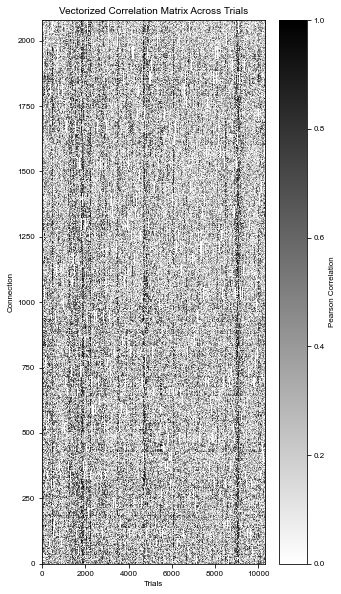

In [26]:
plot_vectorized_correlation_matrix(correlation_matrix)

In [24]:
con_ids = con_trial_clean.assign(Con_ID=con_trial_clean['Con_ID']).set_index(['Stim', 'Chan'])['Con_ID']

In [25]:
sc = con_trial_clean.Stim.values[0]
for sc in np.unique(con_trial_clean.Stim):
    con_id_sc = np.unique(con_trial_clean.loc[con_trial_clean.Stim ==sc, 'Con_ID'])
    trials_sc = np.unique(con_trial_clean.loc[con_trial_clean.Stim ==sc, 'Num'])
    correlation_matrix[con_id_sc[:, None], trials_sc] = np.nan

In [27]:
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler

k = 2
if correlation_matrix.ndim ==3:
    corr_matrix = correlation_matrix.reshape(-1, correlation_matrix.shape[2])
    corr_matrix = abs(corr_matrix)
else:
    corr_matrix = abs(correlation_matrix)
# Ensure corr_matrix is a numpy array, handling NaN by filling them with 0
# Symmetric NMF doesn't handle NaN, so we replace NaNs with the mean of the matrix
nan_mask = np.isnan(corr_matrix)
mean_val = np.nanmean(corr_matrix)
corr_matrix_filled = np.where(nan_mask, mean_val, corr_matrix)

# Scale the filled correlation matrix to be non-negative since NMF requires non-negative inputs
scaler = MinMaxScaler()
corr_matrix_scaled = scaler.fit_transform(corr_matrix_filled)

# Perform NMF
model = NMF(n_components=k, init='random', random_state=0)
W = model.fit_transform(corr_matrix_scaled)
H = model.components_



T:\EL_experiment\Codes\CCEP_human\Python_Analysis\venv\lib\site-packages\sklearn\decomposition\_nmf.py:1641: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  ConvergenceWarning,


In [74]:
k = 3
model = NMF(n_components=k, init='random', random_state=0)
W = model.fit_transform(corr_matrix_scaled)
H = model.components_

T:\EL_experiment\Codes\CCEP_human\Python_Analysis\venv\lib\site-packages\sklearn\decomposition\_nmf.py:1641: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  ConvergenceWarning,


In [47]:
trial = np.unique(con_trial_clean.Num)

In [52]:
trial

array([    0,     1,     2, ..., 10340, 10341, 10343], dtype=int64)

In [51]:
len(trial)

10296

In [49]:
hyp_trace = np.zeros((len(trial),))

In [53]:
i = 0
for t in trial:
    hyp_trace[i]= con_trial_clean.loc[con_trial_clean.Num==t, 'Sleep'].values[0]
    i = i+1

In [54]:
hyp_trace[hyp_trace>4] = 0

In [41]:
hyp_trace = con_trial_clean.loc[con_trial_clean.Chan==0, 'Sleep'].values
hyp_trace[hyp_trace>4] = 0

In [ ]:
# Plot the original correlation matrix and the matrix H
fig, axes = plt.subplots(2,2, figsize=(8, 8), gridspec_kw={'width_ratios': [3, 0.45],'height_ratios': [3, 0.45]}, sharey='row', sharex='col')
fig.patch.set_facecolor('xkcd:white')
# Plot the correlation matrix
# sns.heatmap(corr_matrix_scaled, ax=axes[0,0], cmap='binary', vmin =0, vmax = 1)
cax = axes[0,0].imshow(corr_matrix_scaled,aspect='auto', interpolation = 'none', cmap='binary', vmin=0.2, vmax=0.8)
# fig.colorbar(cax, cax)
axes[0,0].set_title('Pearsons Correlation')
# axes[0,0].set_xlabel('Trials')
#axes[0,0].set_xticks([])
axes[0,0].set_ylabel('Connections')
# axes[0].set_aspect('equal', 'box')

# Plot the matrix H
ax_H = axes[1,0]
# sns.heatmap(H, ax=ax_H, cmap='hot', vmin  =np.percentile(H, 20), vmax= np.percentile(H, 95))
ax_H.imshow(H, cmap='hot',aspect='auto', interpolation = 'none',vmin  =np.percentile(H, 20), vmax= np.percentile(H, 95))
# ax_H.set_title('NMF Components (H)')
ax_H.set_ylabel('NMF Components (H)')
ax_H.set_xlabel('Trials')

# ax_H.set_yticks([0,1])
# ax_H.set_yticklabels(['C1', 'C2'])
ax_H.xaxis.set_ticks_position('bottom')
# ax_H.set_aspect(H.shape[1]/20, 'box')

# Plot the matrix H
ax_W = axes[0,1]
# ax_W.matshow(W, cmap='hot', vmin  =np.percentile(W, 20), vmax= np.percentile(W, 95))
ax_W.imshow(W, cmap='hot',aspect='auto', interpolation = 'none', vmin  =np.percentile(W, 20), vmax= np.percentile(W, 95))
# sns.heatmap(W, ax=ax_W, cmap='hot', vmin  =np.percentile(W, 20), vmax = np.percentile(W, 95))
ax_W.set_title('NMF Components (W)')

# Make last subplot empty, hide axes
axes[1,1].axis('off')

#plt.tight_layout()
plt.show()

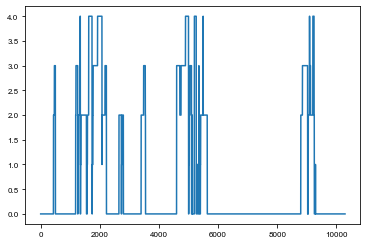

In [55]:
plt.plot(np.arange(len(hyp_trace)),hyp_trace)

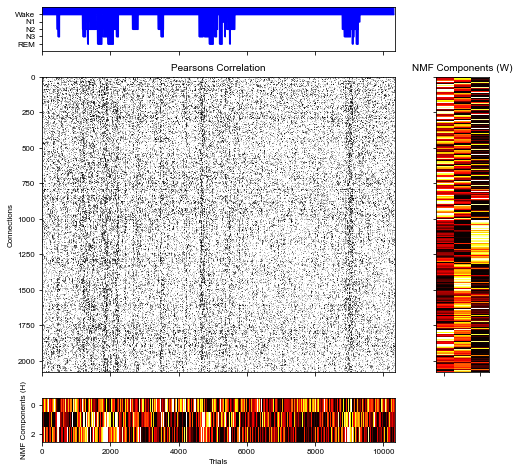

In [148]:
# Plot the original correlation matrix and the matrix H
fig, axes = plt.subplots(3,2, figsize=(8, 8), gridspec_kw={'width_ratios': [3, 0.45],'height_ratios': [0.45,3, 0.45]}, sharey='row', sharex='col')
fig.patch.set_facecolor('xkcd:white')
# Plot the correlation matrix
# sns.heatmap(corr_matrix_scaled, ax=axes[0,0], cmap='binary', vmin =0, vmax = 1)

ax_hyp = axes[0,0]
ax_hyp.plot(np.arange(len(hyp_trace)),hyp_trace, color ='b')
ax_hyp.fill_between(np.arange(len(hyp_trace)),hyp_trace,np.zeros((len(hyp_trace),))-1, color ='b')
ax_hyp.invert_yaxis()
ax_hyp.set_ylim([5, -1])
ax_hyp.set_yticks([0,1,2,3,4], labels=['Wake', 'N1', 'N2', 'N3', 'REM'])


ax_corr = axes[1,0]
cax = ax_corr.imshow(corr_matrix_scaled,aspect='auto', interpolation = 'none', cmap='binary', vmin=0.3, vmax=1)
# fig.colorbar(cax, cax)
ax_corr.set_title('Pearsons Correlation')
# axes[0,0].set_xlabel('Trials')
#axes[0,0].set_xticks([])
ax_corr.set_ylabel('Connections')
# axes[0].set_aspect('equal', 'box')

# Plot the matrix H
ax_H = axes[2,0]
# sns.heatmap(H, ax=ax_H, cmap='hot', vmin  =np.percentile(H, 20), vmax= np.percentile(H, 95))
ax_H.imshow(H, cmap='hot',aspect='auto', interpolation = 'none',vmin  =np.percentile(H, 20), vmax= np.percentile(H, 95))
# ax_H.set_title('NMF Components (H)')
ax_H.set_ylabel('NMF Components (H)')
ax_H.set_xlabel('Trials')

# ax_H.set_yticks([0,1])
# ax_H.set_yticklabels(['C1', 'C2'])
ax_H.xaxis.set_ticks_position('bottom')
# ax_H.set_aspect(H.shape[1]/20, 'box')

# Plot the matrix H
ax_W = axes[1,1]
# ax_W.matshow(W, cmap='hot', vmin  =np.percentile(W, 20), vmax= np.percentile(W, 95))
ax_W.imshow(W, cmap='hot',aspect='auto', interpolation = 'none', vmin  =np.percentile(W, 20), vmax= np.percentile(W, 95))
# sns.heatmap(W, ax=ax_W, cmap='hot', vmin  =np.percentile(W, 20), vmax = np.percentile(W, 95))
ax_W.set_title('NMF Components (W)')

# Make last subplot empty, hide axes
axes[0,1].axis('off')
axes[2,1].axis('off')
#plt.tight_layout()
plt.show()

In [63]:
ax_h = fig.add_subplot(gs[0, 0])
plt.plot(stimlist_hypno.ix_chron, stimlist_hypno.sleep, c=[0,0,0], linewidth=2)
plt.axhspan(-1, 0.2, color=color_elab[0,:])
plt.fill_between(stimlist_hypno.ix_chron,stimlist_hypno.sleep,np.zeros((len(stimlist_hypno.ix_chron),))-1, color=color_elab[0,:])
#plt.ylabel('score', fontsize=25)
plt.yticks([0,1,2,3,4], ['Wake','N1','N2','N3','REM'])
plt.ylim([-1,5])
plt.gca().invert_yaxis()
#plt.xticks(x_tick1,x_ax_h )
plt.xticks([])

plt.tick_params(axis="y", labelsize=18)
plt.xlim([np.min(np.floor(x_ax_block))+1.7, np.max(np.ceil(x_ax_block))-0.3])

NameError: name 'gs' is not defined

In [ ]:
stop

## CONNECTION EXAMPLES

In [ ]:
import scipy as sp

In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests
import numpy as np
data = sm.datasets.macrodata.load_pandas()
data = data.data[["realgdp", "realcons"]].pct_change().dropna()


In [69]:
trial = np.unique(con_trial_clean.Num)

In [73]:
np.unique(con_trial_clean.Num)

array([    0,     1,     2, ..., 10340, 10341, 10343], dtype=int64)

In [70]:
trial.shape

(10296,)

In [72]:
EEG_resp.shape

(87, 10344, 2000)

In [68]:
H.shape

(2, 10344)

C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\IPython\core\interactiveshell.py:2940: PerformanceWarning: indexing past lexsort depth may impact performance.
  return runner(coro)


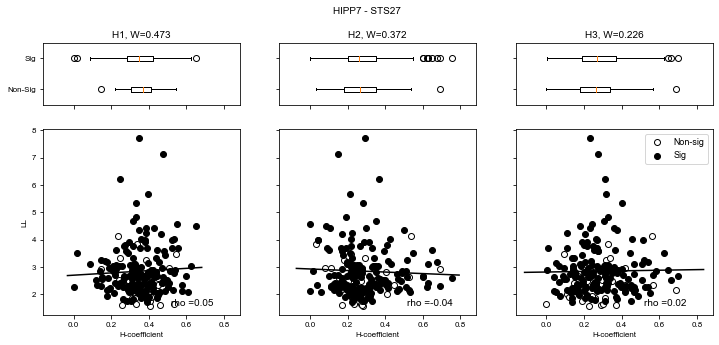

In [135]:
sc = 6
rc = 26
con_ID_sel = np.unique(con_ids.get((sc, rc), -1))[0]
fig, axes = plt.subplots(2, k, figsize=(k*4, 5), sharex =True, gridspec_kw={'height_ratios': [1,3]}, sharey='row')
fig.patch.set_facecolor('xkcd:white')
plt.suptitle(labels_all[sc]+' - '+labels_all[rc] )
for i in range(k):
    ax_boxplot = axes[0,i]
    ax = axes[1,i]
    ax_boxplot.set_title('H'+str(i+1)+', W='+str(np.round(W[con_ID_sel,i],3)))
    ax = axes[1,i]
    boxes=[]
    for sig_val in [0,1]:
        num_trials = np.unique(con_trial.loc[(con_trial.Stim==sc)&(con_trial.Chan==rc)&(con_trial.Sig==sig_val), 'Num'])
        H_val = H[i,num_trials]
        LL_val = con_trial.loc[(con_trial.Stim==sc)&(con_trial.Chan==rc)&(con_trial.Sig==sig_val), 'LL'].values
        ax.scatter(H_val, LL_val, color = [1-sig_val,1-sig_val,1-sig_val], edgecolor = [0,0,0])
        
        boxes.append(H_val)
    if i ==0:
        ax.set_ylabel('LL')
    ax.set_xlabel('H-coefficient')
    ax_boxplot.boxplot(boxes,vert=False)
    ax_boxplot.set_yticks([1,2])
    ax_boxplot.set_yticklabels(['Non-Sig', 'Sig'])
    # add correlation
    num_trials = np.unique(con_trial.loc[(con_trial.Stim==sc)&(con_trial.Chan==rc), 'Num'])
    H_val = H[i,num_trials]
    LL_val = con_trial.loc[(con_trial.Stim==sc)&(con_trial.Chan==rc), 'LL'].values
    m, b = np.polyfit(H_val, LL_val, 1)
    X_plot = np.linspace(ax.get_xlim()[0],ax.get_xlim()[1],100)
    ax.plot(X_plot, m*X_plot + b, '-', color= 'k')
    
    r, p = scipy.stats.pearsonr(x=H_val, y=LL_val)
    ax.text(.65, .05, "rho ={:.2f}".format(r), transform=ax.transAxes)
        
ax.legend(['Non-sig','Sig'])

In [151]:
con_trial.insert(5, 'rho_pred', np.nan)

C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\IPython\core\interactiveshell.py:2940: PerformanceWarning: indexing past lexsort depth may impact performance.
  return runner(coro)


<AxesSubplot:xlabel='rho_pred', ylabel='LL'>

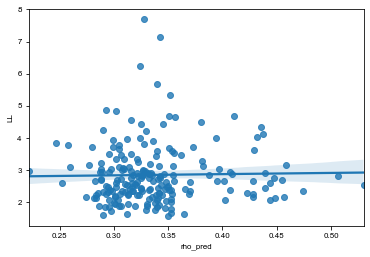

In [185]:
sc = 6
rc = 26
con_ID_sel = np.unique(con_ids.get((sc, rc), -1))[0]
num_con = np.unique(con_trial.loc[(con_trial.Stim==sc)&(con_trial.Chan==rc), 'Num'])
rho_pred = np.zeros((len(num_con),))
for i in range(k):
    coeff = H[i, num_con] * W[con_ID_sel, i]
    
    rho_pred = rho_pred+coeff
    
con_trial.loc[(con_trial.Stim==sc)&(con_trial.Chan==rc), 'rho_pred'] = rho_pred

data_plot = con_trial.loc[(con_trial.Stim==sc)&(con_trial.Chan==rc)].reset_index(drop=True)
sns.regplot(x= 'rho_pred', y= 'LL', data = data_plot)

C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\IPython\core\interactiveshell.py:2940: PerformanceWarning: indexing past lexsort depth may impact performance.
  return runner(coro)
C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\IPython\core\interactiveshell.py:2940: PerformanceWarning: indexing past lexsort depth may impact performance.
  return runner(coro)
C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\IPython\core\interactiveshell.py:2940: PerformanceWarning: indexing past lexsort depth may impact performance.
  return runner(coro)


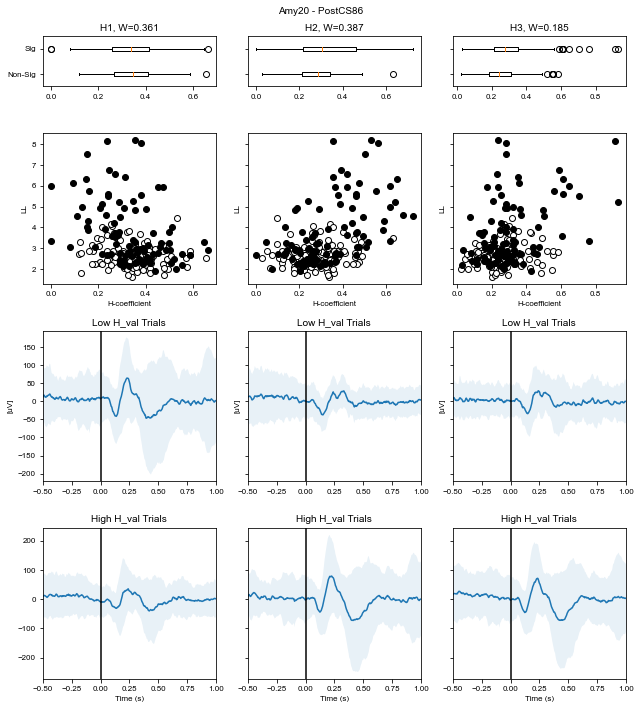

In [150]:
sc = 19
rc = 85
fig, axes = plt.subplots(4, k, figsize=(k*3, 10), sharey='row', gridspec_kw={'height_ratios': [1, 3, 3, 3]})
fig.patch.set_facecolor('xkcd:white')
plt.suptitle(labels_all[sc] + ' - ' + labels_all[rc])

for i in range(k):
    con_ID_sel = np.unique(con_ids.get((sc, rc), -1))[0]
    
    # First row: Box plots
    ax_boxplot = axes[0, i]
    ax_boxplot.set_title('H'+str(i+1)+', W='+str(np.round(W[con_ID_sel, i], 3)))
    boxes = []
    for sig_val in [0, 1]:
        num_trials = np.unique(con_trial.loc[(con_trial.Stim == sc) & (con_trial.Chan == rc) & (con_trial.Sig == sig_val), 'Num'])
        H_val = H[i, num_trials]
        ax_boxplot.boxplot(H_val, positions=[sig_val + 1], vert=False)
    ax_boxplot.set_yticks([1, 2])
    ax_boxplot.set_yticklabels(['Non-Sig', 'Sig'])

    # Second row: Scatter plots and correlation
    ax_scatter = axes[1, i]
    for sig_val in [0, 1]:
        num_trials = np.unique(con_trial.loc[(con_trial.Stim == sc) & (con_trial.Chan == rc) & (con_trial.Sig == sig_val), 'Num'])
        H_val = H[i, num_trials]
        LL_val = con_trial.loc[(con_trial.Stim == sc) & (con_trial.Chan == rc) & (con_trial.Sig == sig_val), 'LL'].values
        ax_scatter.scatter(H_val, LL_val, color=[1 - sig_val, 1 - sig_val, 1 - sig_val], edgecolor=[0, 0, 0])
    ax_scatter.set_ylabel('LL')
    ax_scatter.set_xlabel('H-coefficient')
    
    # Third and Fourth rows: EEG response plots for low and high H_val trials
    num_trials = np.unique(con_trial.loc[(con_trial.Stim == sc) & (con_trial.Chan == rc), 'Num'])
    H_val = H[i, num_trials]
    num_trials_low = num_trials[H_val < np.median(H_val)]
    num_trials_high = num_trials[H_val > np.median(H_val)]

    # Low H_val Trials
    mn_low = np.mean(EEG_resp[rc, num_trials_low, :], axis=0)
    st_low = np.std(EEG_resp[rc, num_trials_low, :], axis=0)
    axes[2, i].plot(x_ax, mn_low)
    axes[2, i].fill_between(x_ax, mn_low - st_low, mn_low + st_low, alpha=0.1)
    axes[2, i].axvline(0, color='k')
    axes[2, i].set_ylabel('[uV]')
    axes[2, i].set_title('Low H_val Trials')
    axes[2, i].set_xlim([-0.5, 1])
    
    # High H_val Trials
    mn_high = np.mean(EEG_resp[rc, num_trials_high, :], axis=0)
    st_high = np.std(EEG_resp[rc, num_trials_high, :], axis=0)
    axes[3, i].plot(x_ax, mn_high)
    axes[3, i].fill_between(x_ax, mn_high - st_high, mn_high + st_high, alpha=0.1)
    axes[3, i].axvline(0, color='k')
    axes[3, i].set_xlim([-0.5, 1])
    axes[3, i].set_title('High H_val Trials')
    axes[3, i].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

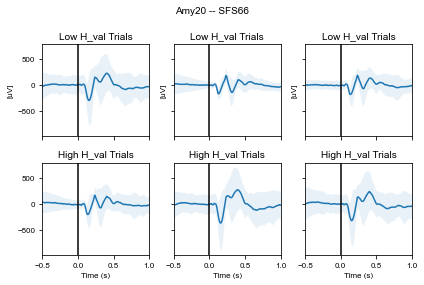

In [123]:

num_trials = np.unique(con_trial.loc[(con_trial.Stim==sc)&(con_trial.Chan==rc), 'Num'])

# Create subplots
fig, axes = plt.subplots(2,k, figsize=(6, 4), sharex = True, sharey =True)
fig.patch.set_facecolor('xkcd:white')
plt.suptitle(labels_all[sc]+ ' -- '+labels_all[rc])
for i in range(k):
    H_val = H[i,num_trials]
    # Split trials based on the median of H_val
    num_trials_low = num_trials[H_val < np.median(H_val)]
    num_trials_high = num_trials[H_val > np.median(H_val)]

    
    
    # Plot for low H_val trials
    mn_low = np.mean(EEG_resp[rc, num_trials_low, :], axis=0)
    st_low = np.std(EEG_resp[rc, num_trials_low, :], axis=0)
    axes[0,i].plot(x_ax, mn_low, label='Low H_val Trials')
    axes[0,i].fill_between(x_ax, mn_low - st_low, mn_low + st_low, alpha=0.1)
    axes[0,i].axvline(0, color='k')
    axes[0,i].set_title('Low H_val Trials')
    axes[0,i].set_ylabel('[uV]')

    # Plot for high H_val trials
    mn_high = np.mean(EEG_resp[rc, num_trials_high, :], axis=0)
    st_high = np.std(EEG_resp[rc, num_trials_high, :], axis=0)
    axes[1,i].plot(x_ax, mn_high, label='High H_val Trials')
    axes[1,i].fill_between(x_ax, mn_high - st_high, mn_high + st_high, alpha=0.1)
    axes[1,i].axvline(0, color='k')
    axes[1,i].set_xlim([-0.5, 1])
    axes[1,i].set_title('High H_val Trials')
    axes[1,i].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

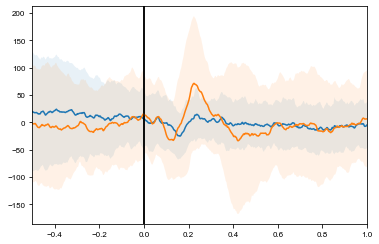

In [109]:

num_trials_low = num_trials[H_val<np.median(H_val)]
num_trials_high = num_trials[H_val>np.median(H_val)]

mn = np.mean(EEG_resp[rc, num_trials_low,:],0)
st = np.std(EEG_resp[rc, num_trials_low,:],0)
plt.plot(x_ax, mn)
plt.fill_between(x_ax, mn-st, mn+st, alpha = 0.1)
plt.xlim([-0.5, 1])
plt.axvline(0, color= 'k')
# second subplot
mn = np.mean(EEG_resp[rc, num_trials_high,:],0)
st = np.std(EEG_resp[rc, num_trials_high,:],0)
plt.plot(x_ax, mn)
plt.fill_between(x_ax, mn-st, mn+st, alpha = 0.1)
plt.xlim([-0.5, 1])
plt.axvline(0, color= 'k')

In [ ]:
h5_file = path_patient_analysis + '\\' + folder + '\\' + cond_folder + '\\data\\EEG_' + cond_folder + '.h5'
if os.path.isfile(h5_file):
    print('loading h5')
    EEG_resp = h5py.File(h5_file)
    EEG_resp = EEG_resp['EEG_resp']
